# Brazilian E-Commerce Sales Analysis (Olist Dataset)

This project analyzes the Brazilian Olist e-commerce dataset.

The goal is to understand sales performance, customer behavior, delivery efficiency and seller performance.

We will combine multiple datasets and perform exploratory analysis to answer key business questions.

Tools used:

Python  
Pandas  
NumPy  
Matplotlib  
Seaborn

## Business Questions

Some questions we want to answer:

• How has revenue changed over time?  
• Which product categories sell the most?  
• Which cities generate the most orders?  
• Which sellers generate the most revenue?  
• How long does delivery take?  
• Do delivery delays affect customer reviews?  
• Which payment methods are most used?

## Import Libraries

In [63]:
# basic libraries for analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

from unidecode import unidecode  # Convert non-ASCII characters to ASCII
# display settings
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")
print('libraries imported sucessfully')

libraries imported sucessfully


## Load Datasets

In [31]:
# load all csv files

customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
category_translation = pd.read_csv("product_category_name_translation.csv")

## Dataset Size

In [53]:
# check shape of each dataset

datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)
geolocation (1000163, 5)


## Preview Data

In [33]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [35]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [34]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [36]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [37]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [38]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [39]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## Dataset Info

In [41]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [42]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [43]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [44]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


## Data Structure

The dataset follows a relational structure.

Customers → Orders → Order Items → Products → Sellers

Orders are also connected with:

Payments  
Reviews

Key columns used for joins:

customer_id  
order_id  
product_id  
seller_id

## DATA CLEANING

### Data Cleaning
Before analysis we need to clean the data.

Main tasks:
- check missing values
- convert date columns
- remove duplicates
- handle missing values

### Check Missing Values

In [77]:
# check missing values

customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [78]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [79]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [80]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

### Convert Date Columns

In [84]:
# convert order dates to datetime

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])

orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])

orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [88]:
# convert shipping date to datetime
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [92]:
# convert reviews date to datetime
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

#### Convert Product Category Names to English

In [176]:
# merge category translation to convert Portuguese names to English

products = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [177]:
# rename the english column for easier use

products.rename(
    columns={"product_category_name_english": "product_category_english"},
    inplace=True
)

In [179]:
# drop original portuguese column

products.drop("product_category_name", axis=1, inplace=True)

### Check Duplicates

In [115]:
customers.duplicated().sum()
orders.duplicated().sum()
order_items.duplicated().sum()
products.duplicated().sum()
reviews.duplicated().sum()

# No duplicates found

np.int64(0)

### Handle Missing Values

In [95]:
# fill missing product categories

products['product_category_name'] = products['product_category_name'].fillna("unknown")

In [96]:
# replace missing review comments with empty text

reviews['review_comment_title'] = reviews['review_comment_title'].fillna("")

reviews['review_comment_message'] = reviews['review_comment_message'].fillna("")

### Drop Unnecessary Columns

Some columns are not useful for our analysis, so we remove them to keep the dataset clean.

In [ ]:
products = products.drop(columns=[
    'product_name_lenght',
    'product_description_lenght',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_photos_qty'
])

## Feature Engineering

We create new columns that will help in analysis.

- order year and month
- delivery time
- delivery delay
- order value

### Order Date Features

In [116]:
# extract year, month and day from purchase timestamp

orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_month'] = orders['order_purchase_timestamp'].dt.month
orders['order_day'] = orders['order_purchase_timestamp'].dt.day

In [117]:
orders[['order_purchase_timestamp','order_year','order_month']].head()

,order_purchase_timestamp,order_year,order_month
0,2017-10-02 10:56:33,2017,10
1,2018-07-24 20:41:37,2018,7
2,2018-08-08 08:38:49,2018,8
3,2017-11-18 19:28:06,2017,11
4,2018-02-13 21:18:39,2018,2


### Delivery Time
Number of days between purchase and delivery

In [119]:
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']).dt.days

In [120]:
orders[['delivery_time']].head()

,delivery_time
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0


### Delivery Delay
Difference between actual delivery and estimated delivery

In [121]:
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']).dt.days

In [122]:
orders[['delivery_delay']].head()

,delivery_delay
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


-positive value  → delayed delivery
-negative value  → delivered early

### Order Value
Total price paid for each item

In [124]:
order_items['order_value'] = order_items['price'] + order_items['freight_value']

In [129]:
order_items[['price','freight_value','order_value']].head()


,price,freight_value,order_value
0,58.90,13.29,72.19
1,239.90,19.93,259.83
2,199.00,17.87,216.87
3,12.99,12.79,25.78
4,199.90,18.14,218.04


### Freight Ratio
Shipping cost compared to product price

In [131]:
order_items['freight_ratio'] = order_items['freight_value'] / order_items['price']

In [132]:
order_items[['price','freight_value','freight_ratio']].head()

,price,freight_value,freight_ratio
0,58.90,13.29,0.225637
1,239.90,19.93,0.083076
2,199.00,17.87,0.089799
3,12.99,12.79,0.984604
4,199.90,18.14,0.090745


## Data Merging

The data is stored in multiple tables.

To perform analysis we combine them into one dataset.

In [182]:
# merge all datasets together

order_data = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(payments, on="order_id", how="left")
    .merge(reviews, on="order_id", how="left")
)

In [134]:
order_data.shape

(119143, 39)

In [135]:
order_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,order_day,delivery_time,delivery_delay,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_value,freight_ratio,product_category_name,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,8.0,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,Sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,0.290764,utilidades_domesticas,9350.0,maua,SP,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,8.0,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,Sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,0.290764,utilidades_domesticas,9350.0,maua,SP,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,8.0,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,Sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,0.290764,utilidades_domesticas,9350.0,maua,SP,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,13.0,-6.0,af07308b275d755c9edb36a90c618231,47813,Barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,0.191744,perfumaria,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,9.0,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,Vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,0.120200,automotivo,14840.0,guariba,SP,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,,,2018-08-18,2018-08-22 19:07:58


In [136]:
order_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   order_year                     119143 non-null  int32         
 9   order_month                    119143 non-null  int32         
 10  order_day                      119143 non-null  int32         
 11  

In [137]:
order_data.isnull().sum().sort_values(ascending=False).head(20)

order_delivered_customer_date    3421
delivery_time                    3421
delivery_delay                   3421
order_delivered_carrier_date     2086
review_score                      997
review_id                         997
review_creation_date              997
review_comment_message            997
review_answer_timestamp           997
review_comment_title              997
seller_zip_code_prefix            833
seller_id                         833
product_category_name             833
seller_state                      833
seller_city                       833
freight_ratio                     833
order_value                       833
freight_value                     833
price                             833
order_item_id                     833
dtype: int64

### Missing Values After Merge

Some columns have missing values after merging the datasets.

This happens because:
- not all orders are delivered
- not all customers leave reviews
- some records don't have matching product or seller data

These values are kept as they represent real-world situations.

## Descriptive Statistics

Before visualization, we look at basic statistics of key variables such as price, freight value, delivery time and review scores.

### Summary Statistics

In [139]:
order_data[['price','freight_value','delivery_time','review_score']].describe()

,price,freight_value,delivery_time,review_score
count,118310.000000,118310.000000,115722.000000,118146.000000
mean,120.646603,20.032387,12.022589,4.015582
std,184.109691,15.836850,9.454922,1.400436
min,0.850000,0.000000,0.000000,1.000000
25%,39.900000,13.080000,6.000000,4.000000
50%,74.900000,16.280000,10.000000,5.000000
75%,134.900000,21.180000,15.000000,5.000000
max,6735.000000,409.680000,209.000000,5.000000


### Mean and Median

In [140]:
order_data[['price','freight_value','delivery_time']].mean()

price            120.646603
freight_value     20.032387
delivery_time     12.022589
dtype: float64

In [141]:
order_data[['price','freight_value','delivery_time']].median()

price            74.90
freight_value    16.28
delivery_time    10.00
dtype: float64

### Variance and Standard Deviation

In [142]:
order_data[['price','freight_value','delivery_time']].var()

price            33896.378262
freight_value      250.805832
delivery_time       89.395554
dtype: float64

In [143]:
order_data[['price','freight_value','delivery_time']].std()

price            184.109691
freight_value     15.836850
delivery_time      9.454922
dtype: float64

### Skewness
Check if the data is symmetric or skewed

In [144]:
order_data[['price','freight_value','delivery_time']].skew()

price            7.892574
freight_value    5.543384
delivery_time    3.846872
dtype: float64

### Kurtosis
Shows how heavy the tails of the distribution are

In [145]:
order_data[['price','freight_value','delivery_time']].kurt()

price            119.154943
freight_value     57.635327
delivery_time     39.949146
dtype: float64

### Review Score Distribution

In [146]:
order_data['review_score'].value_counts()

review_score
5.0    66343
4.0    22319
1.0    15428
3.0     9894
2.0     4162
Name: count, dtype: int64

### Key Takeaways

- Product prices vary significantly across the marketplace.
- Freight costs are generally small relative to product prices.
- Most deliveries happen within 10–15 days.
- Customer satisfaction is generally high with most reviews rated 4 or 5.

## Outlier Detection

Outliers are extreme values that differ significantly from the rest of the data.

We check outliers for key variables:
- product price
- freight value
- delivery time

### Price Distribution

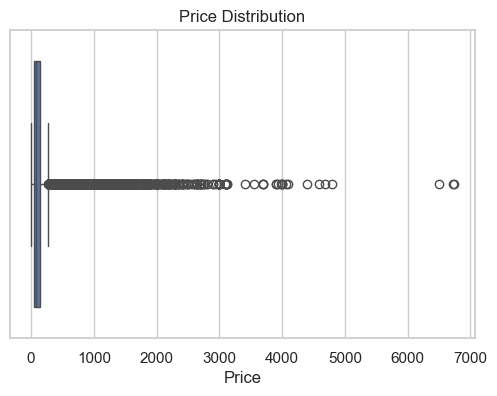

In [147]:
plt.figure(figsize=(6,4))
sns.boxplot(x=order_data['price'])

plt.title("Price Distribution")
plt.xlabel("Price")

plt.show()

#### Insight
Most product prices fall within a reasonable range, but a few products have extremely high prices which appear as outliers.

### Freight Value Distribution

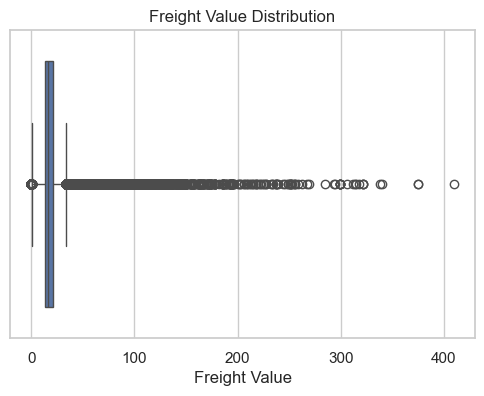

In [149]:
plt.figure(figsize=(6,4))
sns.boxplot(x=order_data['freight_value'])

plt.title("Freight Value Distribution")
plt.xlabel("Freight Value")

plt.show()

#### Insight
Freight costs are usually low compared to product prices, but some orders have unusually high shipping costs.

### Delivery Time Distribution

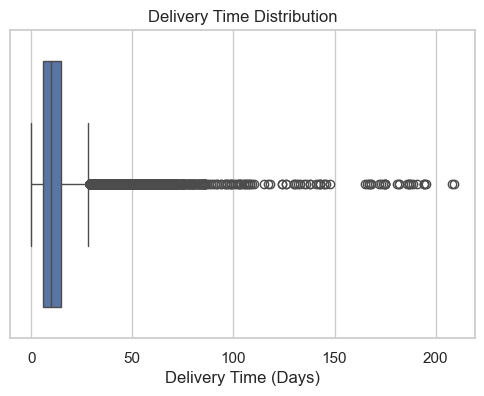

In [151]:
plt.figure(figsize=(6,4))
sns.boxplot(x=order_data['delivery_time'])

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")

plt.show()

#### Insight
Most orders are delivered within a short time, but some deliveries take significantly longer which appear as outliers.

### Detect Outliers using IQR

In [153]:
Q1 = order_data['price'].quantile(0.25)
Q3 = order_data['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = order_data[
    (order_data['price'] < lower_bound) |
    (order_data['price'] > upper_bound)
]

print("Number of price outliers:", price_outliers.shape[0])


Number of price outliers: 8867


In [154]:
order_data[['price','freight_value','delivery_time']].describe()

,price,freight_value,delivery_time
count,118310.000000,118310.000000,115722.000000
mean,120.646603,20.032387,12.022589
std,184.109691,15.836850,9.454922
min,0.850000,0.000000,0.000000
25%,39.900000,13.080000,6.000000
50%,74.900000,16.280000,10.000000
75%,134.900000,21.180000,15.000000
max,6735.000000,409.680000,209.000000


### Observations

- Product price distribution contains several high-value outliers.
- Freight value also shows some extreme values.
- Delivery time has a few unusually long deliveries.

These outliers may represent premium products, long distance shipments or logistics delays.

### Business Interpretation

Outliers in price may represent premium products that contribute higher revenue.

Outliers in freight cost may indicate expensive logistics routes or bulky products.

Long delivery time outliers highlight potential areas where logistics performance could be improved.

## Exploratory Data Analysis

In this section we analyze the dataset to answer key business questions related to sales performance, customer behavior and delivery efficiency.

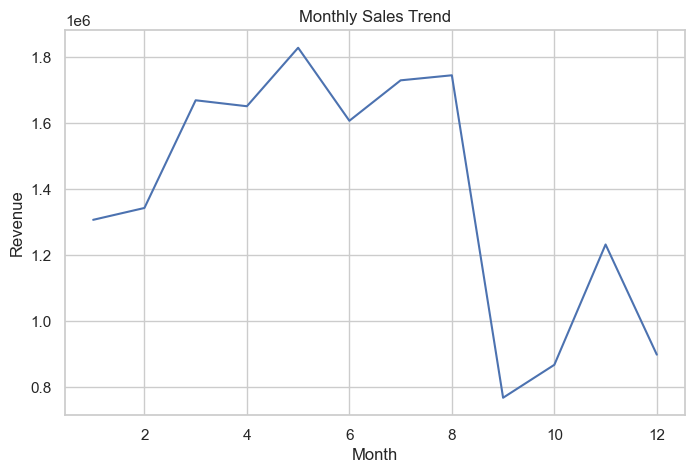

In [156]:
# Business Question: How has sales revenue changed over time?

monthly_sales = order_data.groupby('order_month')['order_value'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(data=monthly_sales, x='order_month', y='order_value')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

#### Insight:

Monthly revenue fluctuates between **~0.75M and ~1.85M**, indicating **clear seasonal demand patterns** across the year.

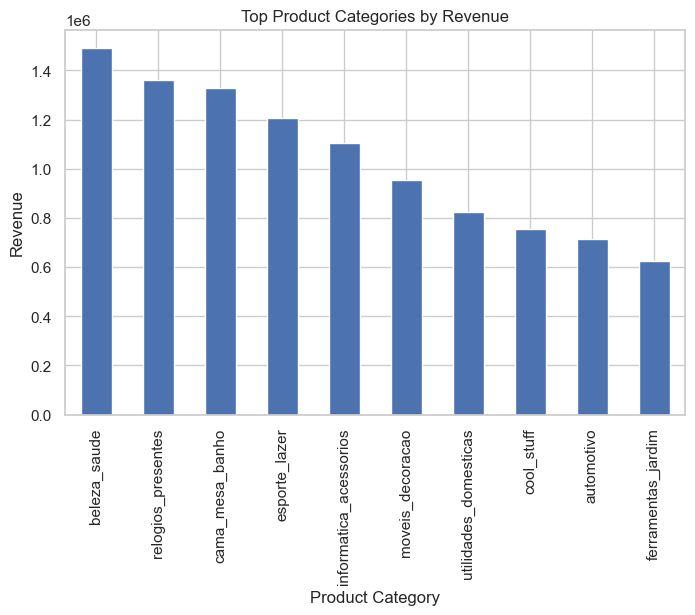

In [157]:
# Business Question: Which product categories generate the most revenue?

category_sales = order_data.groupby('product_category_name')['order_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Top Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.show()

#### Insight:

The top product categories generate **over 1M in revenue each**, with **bed_bath_table and health_beauty** among the highest contributors to total marketplace sales.

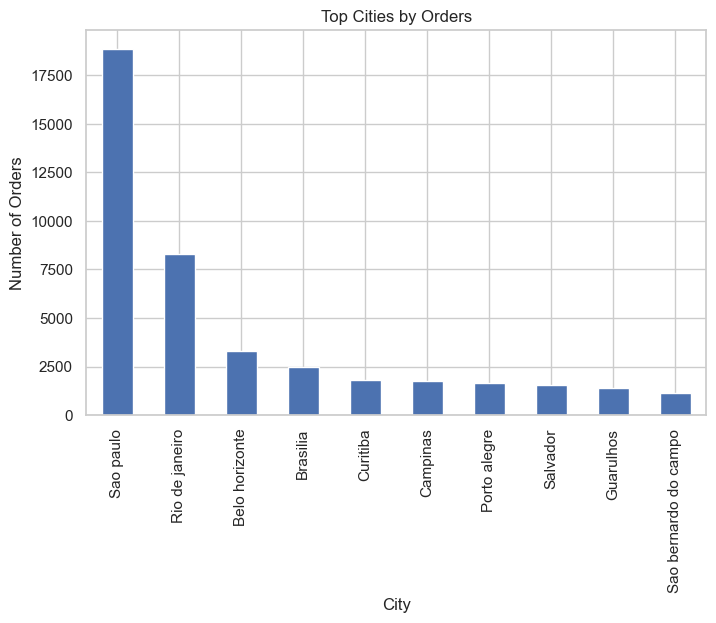

In [158]:
# Business Question: Which cities drive the highest number of orders?

top_cities = order_data['customer_city'].value_counts().head(10)

plt.figure(figsize=(8,5))

top_cities.plot(kind='bar')

plt.title("Top Cities by Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")

plt.show()

#### Insight:

**São Paulo dominates order volume with ~19,000 orders**, significantly higher than the second city (**Rio de Janeiro ~8,000 orders**), showing strong demand concentration in major urban markets.

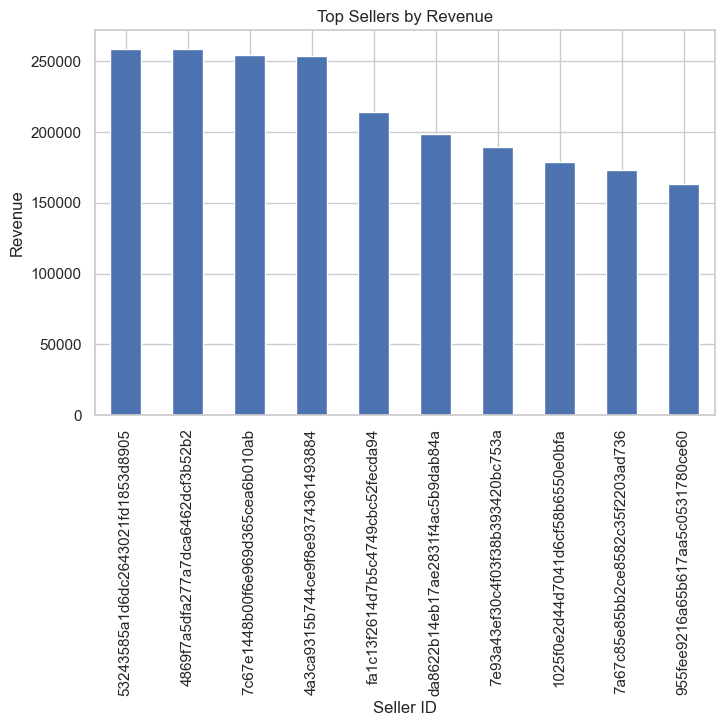

In [159]:
# Business Question: Which sellers contribute the most revenue?

top_sellers = order_data.groupby('seller_id')['order_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top_sellers.plot(kind='bar')

plt.title("Top Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.show()

#### Insight:

The top sellers generate **over 250K in revenue each**, indicating that a small group of sellers contributes disproportionately to marketplace sales.

In [185]:
# Business Question: Which products have the highest freight cost?

high_freight_products = order_data.nlargest(10, 'freight_value')[['product_id','product_category_english','freight_value']]

high_freight_products

,product_id,product_category_english,freight_value
60400,ec31d2a17b299511e7c8627be9337b9b,baby,409.68
89754,a3cd9517ebf5a50dca25acce54f3b171,housewares,375.28
117807,a3cd9517ebf5a50dca25acce54f3b171,housewares,375.28
18747,256a9c364b75753b97bee410c9491ad8,housewares,339.59
114543,97c948ebc8c04b26b7bbb095d4228f2a,health_beauty,338.30
8633,97c948ebc8c04b26b7bbb095d4228f2a,health_beauty,322.10
102905,46e24ce614899e36617e37ea1e4aa6ff,health_beauty,321.88
77758,363a9f5b97bf194da23858be722a7aa5,construction_tools_construction,321.46
118222,7e53e051875b2a0c9f22acd8a9a29a20,industry_commerce_and_business,317.47
17582,363a9f5b97bf194da23858be722a7aa5,construction_tools_construction,314.40


#### Insight:

Some products have **freight costs exceeding 350–400**, which is significantly higher than the average freight value of **~20**, suggesting large or heavy items.

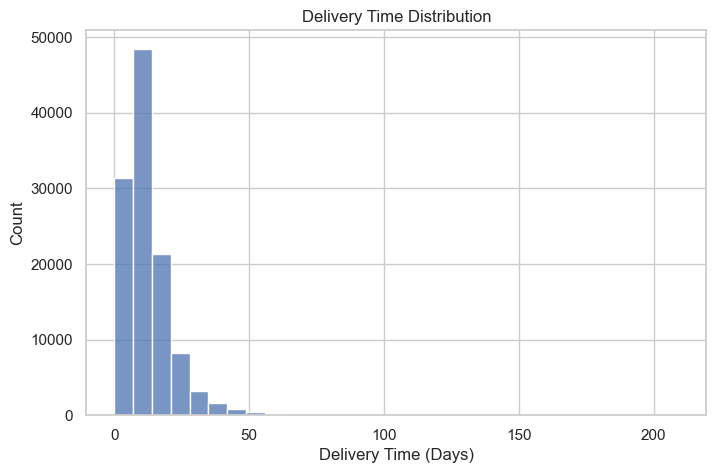

In [164]:
# Business Question: How long does delivery typically take?

plt.figure(figsize=(8,5))

sns.histplot(order_data['delivery_time'], bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Days)")

plt.show()

#### Insight:

Most orders are delivered within **5–20 days**, but a few deliveries exceed **50+ days**, indicating rare but extreme logistics delays.

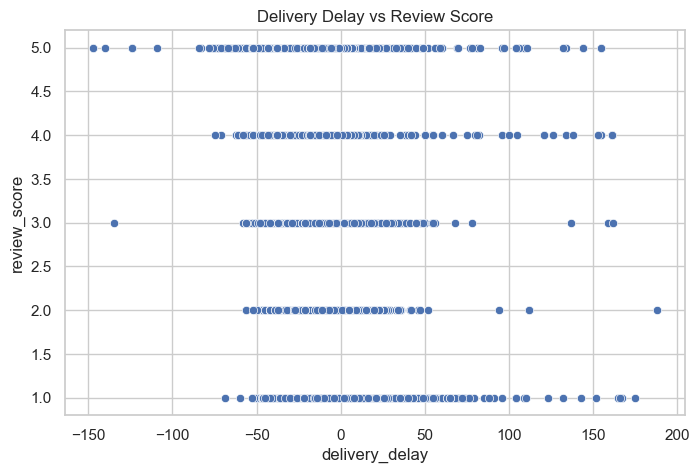

In [165]:
# Business Question: Do delivery delays reduce customer satisfaction?

plt.figure(figsize=(8,5))

sns.scatterplot(x='delivery_delay', y='review_score', data=order_data)

plt.title("Delivery Delay vs Review Score")

plt.show()

#### Insight:

Orders with **longer delivery delays tend to receive lower review scores**, while orders delivered **on time or early often maintain ratings of 4–5 stars**.

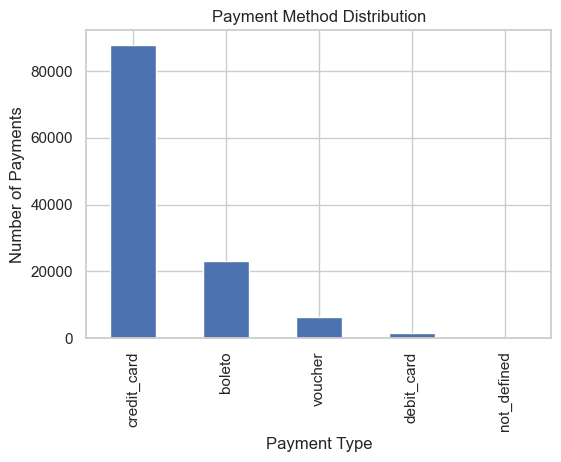

In [168]:
# Business Question: Which payment methods are most popular?

payment_methods = order_data['payment_type'].value_counts()

plt.figure(figsize=(6,4))

payment_methods.plot(kind='bar')

plt.title("Payment Method Distribution")

plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.show()

#### Insight:

**Credit cards dominate payments with over 85,000 transactions**, followed by boleto (~23,000), showing strong customer preference for digital payment methods.

## Correlation Analysis

In this section we analyze the relationship between key numerical variables such as price, freight value, delivery time and review score.

This helps understand how different factors influence customer satisfaction and order value.

In [170]:
corr_matrix = order_data[
    ['price','freight_value','delivery_time','delivery_delay','review_score','order_value']
].corr()

corr_matrix

,price,freight_value,delivery_time,delivery_delay,review_score,order_value
price,1.000000,0.415938,0.061389,-0.003150,-0.004492,0.997160
freight_value,0.415938,1.000000,0.212870,-0.040571,-0.037013,0.483242
delivery_time,0.061389,0.212870,1.000000,0.598278,-0.302750,0.076743
delivery_delay,-0.003150,-0.040571,0.598278,1.000000,-0.228449,-0.006394
review_score,-0.004492,-0.037013,-0.302750,-0.228449,1.000000,-0.007407
order_value,0.997160,0.483242,0.076743,-0.006394,-0.007407,1.000000


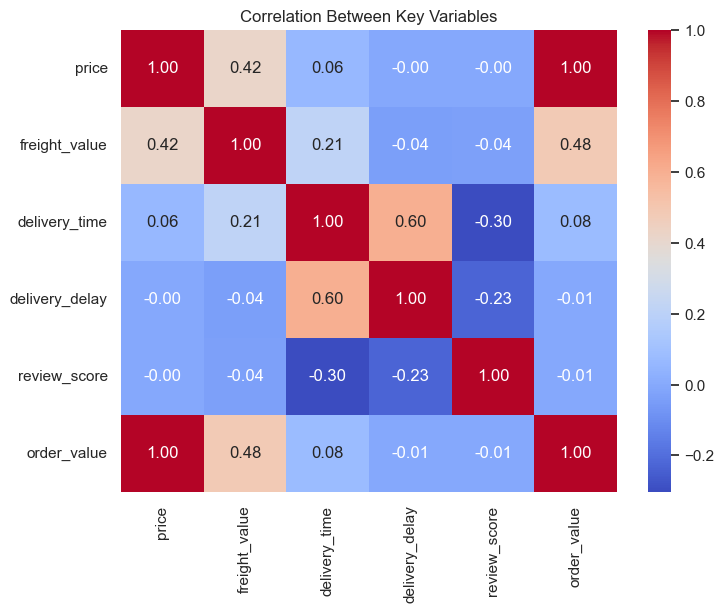

In [171]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Key Variables")

plt.show()

### Key Insights

- **Price and order value show a very strong correlation (0.99)**, meaning total order value is mainly driven by product price.
- **Freight value has a moderate relationship with order value (0.48)**, suggesting higher value orders usually involve higher shipping costs.
- **Delivery time shows a negative correlation with review score (-0.30)**, indicating that longer deliveries tend to reduce customer satisfaction.
- **Delivery time and delivery delay are strongly related (0.60)**, meaning longer deliveries are often associated with delays.

## Business Recommendations

Based on the analysis, the following recommendations can help improve sales performance, customer satisfaction and operational efficiency.

### Recommendations

1. **Improve delivery performance**
Delivery time has a negative relationship with customer review scores. Reducing delivery delays can improve customer satisfaction and ratings.

2. **Focus marketing on high-performing product categories**
A small number of product categories generate the majority of revenue. Promoting these categories can further increase overall sales.

3. **Strengthen operations in high-demand cities**
Most orders originate from a few major cities such as São Paulo and Rio de Janeiro. Improving logistics and delivery efficiency in these regions can significantly impact customer experience.

4. **Support top-performing sellers**
A limited number of sellers generate a large share of marketplace revenue. Providing incentives or partnerships with these sellers can increase platform growth.

5. **Optimize shipping costs for heavy products**
Some products have significantly higher freight costs. Optimizing shipping strategies or warehouse locations can reduce delivery costs and improve profitability.

### Master data for power bi

In [186]:
order_data.to_csv("olist_master_dataset.csv", index=False)